# Sequential MNIST with `ParaLSTM` Quasi-DEER + `accelerated_scan`

This notebook trains the repo's custom **`ParaLSTM`** classifier on:

1. **Sequential MNIST**
2. **Permuted Sequential MNIST**

Each image is treated as a sequence of length 784:

$$
x \in \mathbb{R}^{784 \times 1}
$$

The recurrent layer uses your `ParaLSTM` in **scalar quasi-DEER mode** with `scan_backend="accel_scan"`. This means the 2-by-2 ParaLSTM block Jacobian is reduced to the scalar diagonal approximation and the diagonal affine scan is handled by `accelerated_scan`.

The classifier stays simple:

1. `ParaLSTM` in `mode="deer"`
2. Mean pooling over recurrent outputs
3. LayerNorm
4. Linear classifier

This notebook intentionally requires CUDA and `accelerated-scan`; it does not silently fall back to the PyTorch scan backend.


In [ ]:

from pathlib import Path
import sys
import random
import time

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from src.pararnn import ParaLSTM, make_paralstm_deer_config

Project root: /home/cpt/Documents/Github/Parallel-RNN
Torch version: 2.12.0+cu130


In [ ]:

seed = 42

random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.set_float32_matmul_precision("high")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type != "cuda":
    raise RuntimeError(
        "This notebook is configured for ParaLSTM quasi-DEER with accelerated_scan, "
        "which requires CUDA."
    )

torch.backends.cudnn.benchmark = True
print("GPU:", torch.cuda.get_device_name(0))


Device: cuda
accelerated_scan.warp is available.
GPU: NVIDIA GeForce RTX 3070 Laptop GPU


## Training Settings

In [17]:

batch_size = 64
hidden_size = 64
epochs = 30
learning_rate = 1e-3
weight_decay = 1e-4
grad_clip = 1.0

# ParaLSTM / scalar quasi-DEER settings.
paralstm_num_iters = 4
paralstm_backend = "quasi_deer_autograd_accel_scan"
paralstm_scan_backend = "accel_scan"
paralstm_accel_module = "warp"
paralstm_initial_guess = "f0"
paralstm_recurrent_init_scale = 0.05
paralstm_input_init_scale = 1.0
paralstm_forget_bias_init_value = 1.0

num_workers = 0
pin_memory = device.type == "cuda"



## Dataset

The images are converted to pixel sequences.

The pixels are kept in the natural `[0, 1]` range using `transforms.ToTensor()` only.


In [18]:

class SequentialMNISTDataset(torch.utils.data.Dataset):
    def __init__(self, train=True, permutation=None):
        self.dataset = datasets.MNIST(
            root="./data",
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )

        self.permutation = permutation

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):
        image, label = self.dataset[index]

        x = image.view(-1)

        if self.permutation is not None:
            x = x[self.permutation]

        x = x.unsqueeze(-1)
        return x, label


generator = torch.Generator()
generator.manual_seed(seed)
permutation = torch.randperm(784, generator=generator)


train_seq_dataset = SequentialMNISTDataset(train=True, permutation=None)
test_seq_dataset = SequentialMNISTDataset(train=False, permutation=None)

train_perm_dataset = SequentialMNISTDataset(train=True, permutation=permutation)
test_perm_dataset = SequentialMNISTDataset(train=False, permutation=permutation)


train_seq_loader = DataLoader(
    train_seq_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_seq_loader = DataLoader(
    test_seq_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

train_perm_loader = DataLoader(
    train_perm_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_perm_loader = DataLoader(
    test_perm_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

x_batch, y_batch = next(iter(train_seq_loader))
print("x_batch:", tuple(x_batch.shape))
print("y_batch:", tuple(y_batch.shape))


x_batch: (64, 784, 1)
y_batch: (64,)



## ParaLSTM Classifier

The model is intentionally simple:

1. Your `ParaLSTM` in `mode="deer"`
2. Scalar **quasi-DEER** backend
3. `accelerated_scan` warp backend for the diagonal affine scan
4. Mean pooling over all time steps
5. LayerNorm
6. Linear classifier


In [19]:

class ParaLSTMClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        deer_config = make_paralstm_deer_config(
            backend=paralstm_backend,
            num_iters=paralstm_num_iters,
            tol=None,
            strict_tol=False,
            initial_guess=paralstm_initial_guess,
            scan_backend=paralstm_scan_backend,
            accel_module=paralstm_accel_module,
        )

        self.lstm = ParaLSTM(
            input_size=1,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
            mode="deer",
            deer_config=deer_config,
            dtype=torch.float32,
            recurrent_init_scale=paralstm_recurrent_init_scale,
            input_init_scale=paralstm_input_init_scale,
            forget_bias_init_value=paralstm_forget_bias_init_value,
        )

        self.norm = nn.LayerNorm(hidden_size)
        self.fc = nn.Linear(hidden_size, 10)

        self.init_weights()

    def init_weights(self):
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        output, _ = self.lstm(x)
        pooled = output.mean(dim=1)
        pooled = self.norm(pooled)
        logits = self.fc(pooled)
        return logits


## Quick Forward/Backward Sanity Check

In [20]:

model = ParaLSTMClassifier().to(device)
loss_fn = nn.CrossEntropyLoss()

x_batch = x_batch.to(device, non_blocking=True)
y_batch = y_batch.to(device, non_blocking=True)

model.train()
model.zero_grad(set_to_none=True)

logits = model(x_batch)
loss = loss_fn(logits, y_batch)
loss.backward()
grad_norm = nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

print("logits:", tuple(logits.shape))
print("loss:", float(loss.detach().cpu()))
print("grad norm:", float(grad_norm.detach().cpu() if torch.is_tensor(grad_norm) else grad_norm))
print("last DEER info:")
for key, value in model.lstm.last_deer_infos[0].items():
    if torch.is_tensor(value):
        value = float(value.detach().cpu()) if value.ndim == 0 else tuple(value.shape)
    print(f"  {key}: {value}")

if device.type == "cuda":
    torch.cuda.empty_cache()

del model


logits: (64, 10)
loss: 2.621112823486328
grad norm: 13.92251968383789
last DEER info:
  num_iters: 4
  initial_merit: 263.11767578125
  final_merit: 4.67758763988968e-06
  last_update_error: 0.0009198039770126343
  tol: None
  effective_tol: 0.0001
  strict_tol: False
  stopping_criterion: update
  scan_backend: accel_scan
  quasi: True
  batched: True
  batch_size: 64
  jacobian_backend: explicit_scalar_diag_from_block2
  linearization_backend: custom_scalar_diag_from_block2
  backward_backend: autograd
  cell_variant: cifg_peephole_diag_scalar_quasi
  paralstm_deer_kind: scalar_quasi


## Training and Evaluation

In [21]:

def train_one_epoch(model, loader, optimizer, loss_fn):
    model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in tqdm(loader, leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(x)
        loss = loss_fn(logits, y)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += y.size(0)

    if device.type == "cuda":
        torch.cuda.synchronize()

    return total_loss / total_samples, total_correct / total_samples


@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = loss_fn(logits, y)

        total_loss += loss.item() * y.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_samples += y.size(0)

    return total_loss / total_samples, total_correct / total_samples


In [22]:

def run_task(task_name, train_loader, test_loader):
    model = ParaLSTMClassifier().to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    loss_fn = nn.CrossEntropyLoss()
    history = []

    print(f"Training on {task_name}")

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)

    for epoch in range(1, epochs + 1):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, loss_fn)
        test_loss, test_acc = evaluate(model, test_loader, loss_fn)

        scheduler.step()

        epoch_time = time.time() - start_time

        history.append({
            "task": task_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "test_loss": test_loss,
            "train_acc": train_acc,
            "test_acc": test_acc,
            "epoch_time": epoch_time
        })

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train acc: {train_acc * 100:.2f}% | "
            f"test acc: {test_acc * 100:.2f}% | "
            f"train loss: {train_loss:.4f} | "
            f"test loss: {test_loss:.4f} | "
            f"time: {epoch_time:.1f}s"
        )

    if device.type == "cuda":
        peak_mb = torch.cuda.max_memory_allocated(device) / 1024**2
        print(f"Peak CUDA memory allocated: {peak_mb:.1f} MB")

    return model, pd.DataFrame(history)


## Train on Sequential MNIST

In [23]:

seq_model, seq_history = run_task(
    "Sequential MNIST",
    train_seq_loader,
    test_seq_loader
)


Training on Sequential MNIST


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 01/30 | train acc: 22.16% | test acc: 22.99% | train loss: 2.0873 | test loss: 2.0393 | time: 173.2s


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 02/30 | train acc: 28.18% | test acc: 33.08% | train loss: 1.9521 | test loss: 1.7966 | time: 171.9s


...

Epoch 28/30 | train acc: 64.98% | test acc: 64.84% | train loss: 1.0452 | test loss: 1.0299 | time: 172.6s


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29/30 | train acc: 64.96% | test acc: 64.61% | train loss: 1.0436 | test loss: 1.0288 | time: 172.6s


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 30/30 | train acc: 65.00% | test acc: 64.88% | train loss: 1.0426 | test loss: 1.0282 | time: 172.6s
Peak CUDA memory allocated: 2585.3 MB


## Train on Permuted Sequential MNIST

In [24]:

perm_model, perm_history = run_task(
    "Permuted Sequential MNIST",
    train_perm_loader,
    test_perm_loader
)


Training on Permuted Sequential MNIST


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 01/30 | train acc: 21.58% | test acc: 21.84% | train loss: 2.0959 | test loss: 2.0840 | time: 173.8s


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 02/30 | train acc: 22.48% | test acc: 21.44% | train loss: 2.0700 | test loss: 2.0673 | time: 173.6s


...

Epoch 28/30 | train acc: 37.05% | test acc: 36.81% | train loss: 1.7487 | test loss: 1.7277 | time: 174.6s


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29/30 | train acc: 37.03% | test acc: 36.98% | train loss: 1.7476 | test loss: 1.7267 | time: 174.6s


  0%|          | 0/938 [00:00<?, ?it/s]

Epoch 30/30 | train acc: 37.16% | test acc: 36.88% | train loss: 1.7471 | test loss: 1.7263 | time: 174.5s
Peak CUDA memory allocated: 2585.3 MB


## Best Results

In [25]:

results = pd.concat([seq_history, perm_history], ignore_index=True)

best_results = (
    results
    .sort_values("test_acc", ascending=False)
    .groupby("task", as_index=False)
    .first()
)

best_results["best_test_acc_percent"] = best_results["test_acc"] * 100
best_results[["task", "epoch", "best_test_acc_percent", "train_acc", "test_loss"]]


,task,epoch,best_test_acc_percent,train_acc,test_loss
0,Permuted Sequential MNIST,29,36.98,0.370283,1.726717
1,Sequential MNIST,26,64.94,0.646750,1.034023


## Accuracy Curve

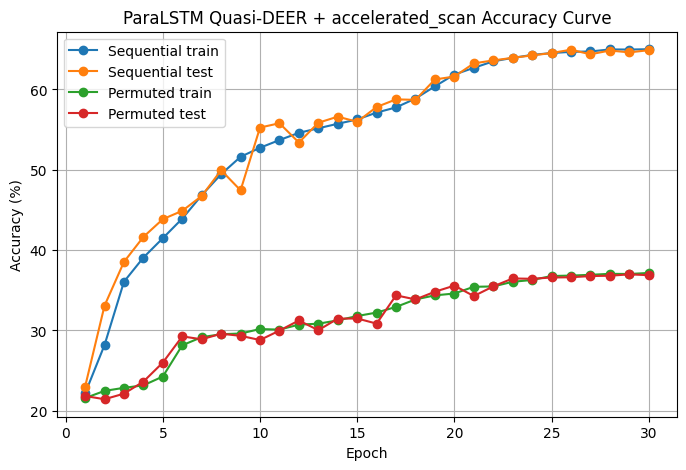

In [26]:

plt.figure(figsize=(8, 5))

plt.plot(seq_history["epoch"], seq_history["train_acc"] * 100, marker="o", label="Sequential train")
plt.plot(seq_history["epoch"], seq_history["test_acc"] * 100, marker="o", label="Sequential test")
plt.plot(perm_history["epoch"], perm_history["train_acc"] * 100, marker="o", label="Permuted train")
plt.plot(perm_history["epoch"], perm_history["test_acc"] * 100, marker="o", label="Permuted test")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ParaLSTM Quasi-DEER + accelerated_scan Accuracy Curve")
plt.grid(True)
plt.legend()
plt.show()


## Loss Curve

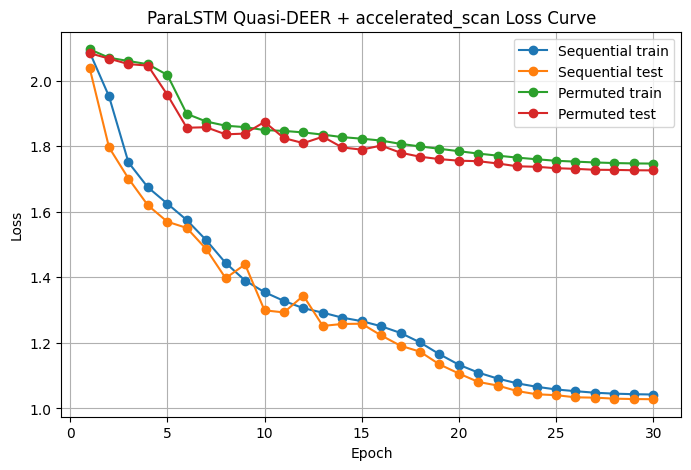

In [27]:

plt.figure(figsize=(8, 5))

plt.plot(seq_history["epoch"], seq_history["train_loss"], marker="o", label="Sequential train")
plt.plot(seq_history["epoch"], seq_history["test_loss"], marker="o", label="Sequential test")
plt.plot(perm_history["epoch"], perm_history["train_loss"], marker="o", label="Permuted train")
plt.plot(perm_history["epoch"], perm_history["test_loss"], marker="o", label="Permuted test")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ParaLSTM Quasi-DEER + accelerated_scan Loss Curve")
plt.grid(True)
plt.legend()
plt.show()
